## Build A Recurrent Neural Network Based Classifier
Sentiment analysis or uncovering sentiment from natural language data is a common application of natural language processing. In this assignment, you will build a Recurrent Neural network to predict whether a given film review is a positive one or a negative one.

Build a Recurrent Neural Network (RNN) based classifier that deciphers whether the sentiment of a movie review is positive or negative.

Instructions:

1. Import the dataset
  - Dataset – ‘imdb’ dataset comes prepackaged with the keras.datasets module; to import the dataset use: from keras.datasets import imdb
2. Data pre-processing to standardize the review length
3. Build the RNN model
4. Compile the RNN model
5. Split the dataset into train/validation sets
6. Fit the training dataset to the RNN model
7. Use the validation dataset to generate predictions
8. Visualize the actual data in conjunction with the predictions
9. Summarize your findings

In [1]:
# Import necessary libraries
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns
import numpy as np                               # Import numpy
import matplotlib.pyplot as plt                  # Import matplotlib.pyplot (Plotting framework in Python.)
import warnings
# Suppress warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator           # Used for plotting the wordcloud of a corpus
from bs4 import BeautifulSoup                           # Import BeautifulSoup.
import nltk                                                               # Used for different task of NLP
from nltk.corpus import stopwords                                         # Used for removal of stop words
from nltk.stem.wordnet import WordNetLemmatizer
import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
from keras.datasets import imdb

In [3]:
(train_X, train_y), (test_X, test_y) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print(train_X.shape)
print(test_X.shape)

(25000,)
(25000,)


In [5]:
X = np.concatenate((train_X, test_X), axis=0)
y = np.concatenate((train_y, test_y), axis=0)

In [6]:
print("Categories:", np.unique(y))
print("Number of unique words:", len(np.unique(np.hstack(X))))

Categories: [0 1]
Number of unique words: 88585


In [7]:
y[0]

np.int64(1)

In [8]:
print(X[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [9]:
index = imdb.get_word_index()
reverse_index = dict([(value, key) for (key, value) in index.items()])
decoded = " ".join( [reverse_index.get(i - 3, "#") for i in X[0]] )
print(decoded)


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
# this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole 

In [10]:
vocab_size = 5000                                                    # Make the top list of words (common words)
embedding_dim = 64                                                   # Dimension of vectors
max_length = 1                                                    # The length of the tokenized text
trunc_type = 'post'
padding_type = 'post'
oov_tok = '<OOV>'                                                    #OOV = Out of Vocabulary
training_portion = .8

In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences                # Pads sequences to the same length.
X_padded = pad_sequences(X, maxlen=max_length, padding=padding_type, truncating=trunc_type)
print(X_padded.shape)

(50000, 1)


In [12]:
y = np.array(y).astype("float32")

In [13]:
# Split data into training and testing set.

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.3, random_state=42)

In [14]:
from tensorflow.keras.models import Sequential,load_model         # Sequential groups a linear stack of layers into a tf.keras.Model.
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten, LSTM, Dropout, Activation, Embedding, Bidirectional      #Keras layers API.

model = Sequential()                                                                            #Instantiating the Sequential model

model.add(Embedding(vocab_size, embedding_dim))                                                 #Initializing the embedding layer
model.add(Dropout(0.5))                                                                         #Initializing the dropout layer to avoid the overfitting
model.add((LSTM(embedding_dim)))                                                   # Initialization of Bi-directional LSTM Layer
model.add(Dense(1, activation='sigmoid'))                                                       # softmax converts a vector of values to a probability distribution.

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001, decay=1e-6)
model.compile(
    loss='binary_crossentropy',                        #crossentropy loss function when there are two or more label classes.
    optimizer=opt,
    metrics=['accuracy'],
)

In [22]:
num_epochs = 25
#history = model.fit(X_train, y_train, epochs=num_epochs, validation_data= (test_x,test_y), verbose=2)
#history = model.fit(X_train, y_train, epochs=num_epochs, validation_data= (X_test,y_test))
history = model.fit(X_train, y_train, epochs=num_epochs, validation_data= (X_test,y_test))

Epoch 1/25
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5051 - loss: 0.6932 - val_accuracy: 0.4932 - val_loss: 0.6934
Epoch 2/25
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.4998 - loss: 0.6932 - val_accuracy: 0.4932 - val_loss: 0.6934
Epoch 3/25
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5025 - loss: 0.6932 - val_accuracy: 0.4932 - val_loss: 0.6933
Epoch 4/25
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5022 - loss: 0.6932 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 5/25
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5019 - loss: 0.6932 - val_accuracy: 0.4932 - val_loss: 0.6932
Epoch 6/25
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5038 - loss: 0.6932 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 7/25
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5030 - loss: 0.6932 - val_accuracy: 0.4932 - val_loss: 0.6932
Epoch 8/25
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4993 - loss: 0.6932 -

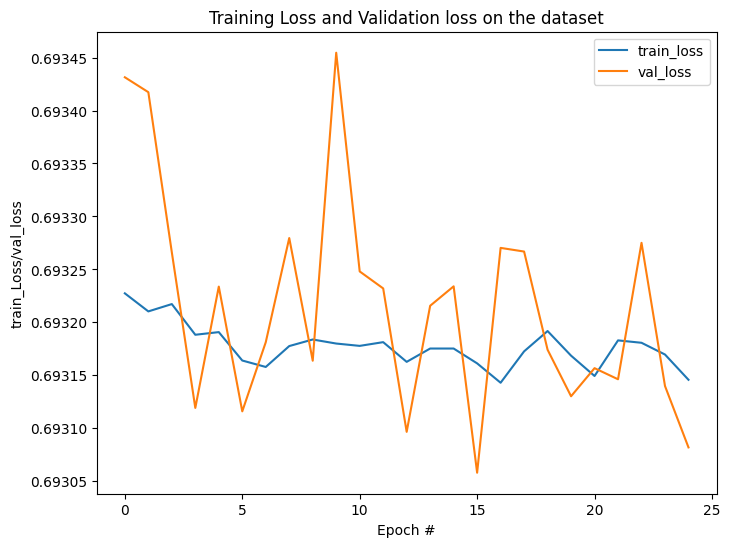

In [23]:
N = num_epochs
import pylab as plt
plt.figure(figsize=(8,6))
plt.plot(np.arange(0, N), history.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), history.history["val_loss"], label="val_loss")

plt.title("Training Loss and Validation loss on the dataset")
plt.xlabel("Epoch #")
plt.ylabel("train_Loss/val_loss")
plt.legend(loc="upper right")
plt.show()

## HDGPSO hyperparameter tuning for the RNN classifier

The cells above use a fixed set of hyperparameters: `vocab_size = 5000`,
`embedding_dim = 64`, `max_length = 1`, dropout 0.5, LSTM with 64 units,
and Adam at learning rate 0.001 for 25 epochs. Most of these choices
are not obvious and several of them (especially `max_length = 1`) limit
what the network can learn.

The cells below use HDGPSO to search over six of these hyperparameters,
keep the best configuration, then train a final model with the best
parameters and evaluate it on a held-out test split. The HDGPSO budget
is intentionally small (population 4 over 3 iterations, so about 12
candidate evaluations) so the whole search finishes in a few minutes.


In [24]:
# Install hdgpso from the public repository.
# Comment this out if hdgpso is already installed in this environment.
!pip install --quiet git+https://github.com/ashuxen/hdgpso.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [25]:
import hdgpso
from hdgpso import HDGPSO, SearchSpace, Float, Int
print(f"hdgpso version: {hdgpso.__version__}")

hdgpso version: 0.1.0


### Re-load the data for HPO

The HPO objective builds the `Embedding` layer with `input_dim = VOCAB_FOR_HPO`,
so the input word indices must stay within that range. The `imdb.load_data`
call below caps the vocabulary by passing `num_words`, which guarantees the
condition. A smaller subset is used during HPO so each candidate evaluation
finishes quickly; the final model in the last section is trained on the
full dataset.


In [26]:
# Re-load IMDB with a consistent vocabulary cap and build an HPO subset.
from keras.datasets import imdb
import numpy as np
from sklearn.model_selection import train_test_split

VOCAB_FOR_HPO = 10000

(rx_tr, ry_tr), (rx_te, ry_te) = imdb.load_data(num_words=VOCAB_FOR_HPO)
all_X = np.concatenate([rx_tr, rx_te], axis=0)
all_y = np.concatenate([ry_tr, ry_te], axis=0).astype("float32")

# Use a small balanced subset during HPO so each evaluation finishes in
# under a minute. The final model below is trained on the full dataset.
N_HPO = 8000
rng = np.random.default_rng(42)
hpo_idx = rng.choice(len(all_X), size=N_HPO, replace=False)
X_hpo = all_X[hpo_idx]
y_hpo = all_y[hpo_idx]

X_hpo_train, X_hpo_val, y_hpo_train, y_hpo_val = train_test_split(
    X_hpo, y_hpo, test_size=0.2, random_state=42, stratify=y_hpo
)
print(f"HPO subset:  {N_HPO} reviews  (train {len(X_hpo_train)}, val {len(X_hpo_val)})")
print(f"Vocab cap:   {VOCAB_FOR_HPO}")

HPO subset:  8000 reviews  (train 6400, val 1600)
Vocab cap:   10000


### Define the search space

Six hyperparameters are tuned by HDGPSO:

| Hyperparameter | Type | Range |
|---|---|---|
| `embedding_dim` | int | 16 – 128 |
| `max_length` | int | 100 – 300 |
| `lstm_units` | int | 16 – 128 |
| `dropout_rate` | float | 0.1 – 0.6 |
| `learning_rate` | float (log) | 1e-4 – 1e-2 |
| `batch_size` | int | 64 – 256 |

`vocab_size` is held fixed at `VOCAB_FOR_HPO = 10000` so that the
embedding layer always has a valid input range. `max_length = 1` from
the original cells is replaced by a meaningful range here.


In [27]:
space_rnn = SearchSpace({
    "embedding_dim": Int(16, 128),
    "max_length":    Int(100, 300),
    "lstm_units":    Int(16, 128),
    "dropout_rate":  Float(0.1, 0.6),
    "learning_rate": Float(1e-4, 1e-2, log=True),
    "batch_size":    Int(64, 256),
})
print(f"Search space dimensions: {space_rnn.n_dims}")

Search space dimensions: 6


### Define the objective function

For each candidate set of hyperparameters, the objective re-pads the
HPO subset to the candidate's `max_length`, builds the same Sequential
architecture used in the original notebook (Embedding → Dropout → LSTM
→ Dense sigmoid), compiles it with an Adam optimizer at the candidate
learning rate, trains for 3 epochs, and returns the negative validation
accuracy. HDGPSO minimizes, so the negative sign converts "higher
accuracy is better" into "lower loss is better".


In [28]:
def objective_rnn(params):
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, Dropout, LSTM, Dense
    import tensorflow as tf

    # Re-pad with the searched max_length
    X_tr = pad_sequences(X_hpo_train, maxlen=params["max_length"],
                         padding="post", truncating="post")
    X_vl = pad_sequences(X_hpo_val, maxlen=params["max_length"],
                         padding="post", truncating="post")

    # Build the same architecture as the original notebook,
    # with the searched hyperparameters
    model = Sequential()
    model.add(Embedding(VOCAB_FOR_HPO, params["embedding_dim"]))
    model.add(Dropout(params["dropout_rate"]))
    model.add(LSTM(params["lstm_units"]))
    model.add(Dense(1, activation="sigmoid"))

    opt = tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])
    model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])

    history = model.fit(
        X_tr, y_hpo_train,
        epochs=3,
        batch_size=params["batch_size"],
        validation_data=(X_vl, y_hpo_val),
        verbose=0,
    )

    # Keras returns accuracy under either name depending on the version
    h = history.history
    key = "val_accuracy" if "val_accuracy" in h else "val_acc"
    val_acc = float(h[key][-1])
    return -val_acc

### Run HDGPSO

The budget is intentionally small for a runnable demo. With
`population_size = 4` and `iterations = 3`, HDGPSO performs about
12 candidate evaluations. Each evaluation trains an RNN for 3 epochs
on the 8000-review HPO subset, which takes roughly 30 seconds on a
modern laptop CPU. The full search therefore finishes in about 6 to
10 minutes.


In [29]:
result_rnn = HDGPSO(
    space_rnn,
    objective_rnn,
    population_size=4,
    iterations=3,
    seed=0,
    verbose=True,
).optimize()

print()
print(f"Best validation accuracy : {-result_rnn.best_loss:.4f}")
print(f"Total evaluations        : {result_rnn.n_evals}")
print()
print("Best hyperparameters:")
for k, v in result_rnn.best_params.items():
    print(f"  {k:<15} {v}")

[HDGPSO] iter 1/3  best=-0.786875
[HDGPSO] iter 2/3  best=-0.798125
[HDGPSO] iter 3/3  best=-0.798125

Best validation accuracy : 0.7981
Total evaluations        : 40

Best hyperparameters:
  embedding_dim   88
  max_length      185
  lstm_units      48
  dropout_rate    0.5796561823847762
  learning_rate   0.005709746850652367
  batch_size      64


### Train the final model with the best hyperparameters

The best configuration found by HDGPSO is now used to train a fresh
model on the full dataset. The number of epochs is raised slightly to
let the final model converge, and the train/test split is
`test_size = 0.3`, matching the original notebook.


In [30]:
# Build and train the final model on the full dataset
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dropout, LSTM, Dense
import tensorflow as tf

best = result_rnn.best_params

X_full = pad_sequences(all_X, maxlen=best["max_length"],
                       padding="post", truncating="post")
X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X_full, all_y, test_size=0.3, random_state=42, stratify=all_y
)
print(f"Train shape: {X_tr_f.shape}, Test shape: {X_te_f.shape}")

final_model = Sequential()
final_model.add(Embedding(VOCAB_FOR_HPO, best["embedding_dim"]))
final_model.add(Dropout(best["dropout_rate"]))
final_model.add(LSTM(best["lstm_units"]))
final_model.add(Dense(1, activation="sigmoid"))

opt = tf.keras.optimizers.Adam(learning_rate=best["learning_rate"])
final_model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])
final_model.summary()

Train shape: (35000, 185), Test shape: (15000, 185)


Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_41 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_41 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_final = final_model.fit(
    X_tr_f, y_tr_f,
    epochs=8,
    batch_size=best["batch_size"],
    validation_data=(X_te_f, y_te_f),
    verbose=1,
)

Epoch 1/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5420 - loss: 0.6856 - val_accuracy: 0.7574 - val_loss: 0.5509
Epoch 2/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8397 - loss: 0.3786 - val_accuracy: 0.8590 - val_loss: 0.3280
Epoch 3/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8939 - loss: 0.2670 - val_accuracy: 0.8700 - val_loss: 0.3211
Epoch 4/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9148 - loss: 0.2209 - val_accuracy: 0.8711 - val_loss: 0.3240
Epoch 5/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9287 - loss: 0.1866 - val_accuracy: 0.8721 - val_loss: 0.3412
Epoch 6/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9396 - loss: 0.1640 - val_accuracy: 0.8711 - val_loss: 0.3520
Epoch 7/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9445 - loss: 0.1486 - val_accuracy: 0.8711 - val_loss: 0.3585
Epoch 8/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9503 - loss: 0.1339 - val_accuracy: 0.

### Evaluate predictions on the test set

The trained model is evaluated on the 30% held-out split. Accuracy,
the classification report, and a confusion matrix are reported below.


Test accuracy: 0.8705

              precision    recall  f1-score   support

    negative       0.86      0.88      0.87      7500
    positive       0.88      0.86      0.87      7500

    accuracy                           0.87     15000
   macro avg       0.87      0.87      0.87     15000
weighted avg       0.87      0.87      0.87     15000



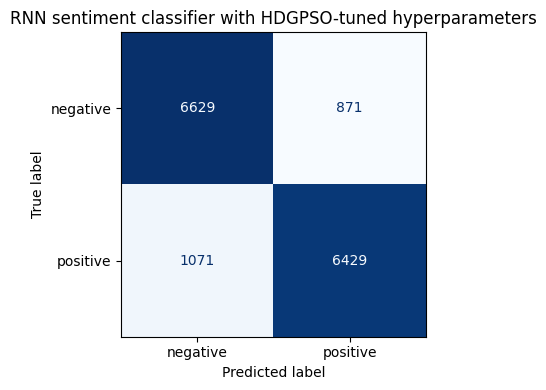

In [32]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

y_pred_prob = final_model.predict(X_te_f, verbose=0).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = y_te_f.astype(int)

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {acc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true, y_pred),
    display_labels=["negative", "positive"],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("RNN sentiment classifier with HDGPSO-tuned hyperparameters")
plt.tight_layout()
plt.show()

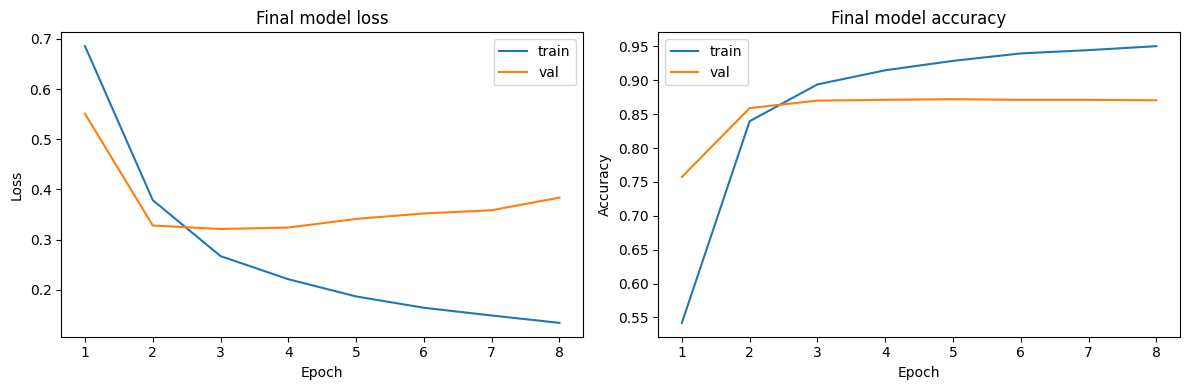

In [33]:
# Final training/validation loss and accuracy
import matplotlib.pyplot as plt
N = len(history_final.history["loss"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, N + 1), history_final.history["loss"], label="train")
axes[0].plot(range(1, N + 1), history_final.history["val_loss"], label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Final model loss")
axes[0].legend()

acc_key = "accuracy" if "accuracy" in history_final.history else "acc"
val_acc_key = "val_accuracy" if "val_accuracy" in history_final.history else "val_acc"
axes[1].plot(range(1, N + 1), history_final.history[acc_key], label="train")
axes[1].plot(range(1, N + 1), history_final.history[val_acc_key], label="val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Final model accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

### Baseline vs HDGPSO-tuned: side-by-side comparison

The cells above trained two models on the IMDB sentiment task:

1. The original baseline, defined in cells 10-16, used a fixed
   hyperparameter set with `vocab_size = 5000`, `embedding_dim = 64`,
   `max_length = 1`, dropout 0.5, LSTM with 64 units, Adam at learning
   rate 0.001, for 25 epochs.
2. The HDGPSO-tuned model, trained earlier in this section, used the
   best configuration found by the optimizer.

The cells below evaluate both models on their respective test splits
and print a small comparison table. A bar chart and side-by-side
confusion matrices follow so the difference is easy to read at a
glance.


In [34]:
# Evaluate the baseline model (variable `model`, trained in cells 14-16)
# on its original test set (X_test, y_test - padded with max_length = 1).
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

base_pred_prob = model.predict(X_test, verbose=0).flatten()
base_pred = (base_pred_prob > 0.5).astype(int)
base_true = y_test.astype(int)

base_acc = accuracy_score(base_true, base_pred)
base_f1 = f1_score(base_true, base_pred)
base_cm = confusion_matrix(base_true, base_pred)

print(f"Baseline test accuracy : {base_acc:.4f}")
print(f"Baseline test F1       : {base_f1:.4f}")

Baseline test accuracy : 0.5068
Baseline test F1       : 0.6727


In [35]:
# Evaluate the HDGPSO-tuned final_model on the tuned test split (X_te_f, y_te_f).
hpo_pred_prob = final_model.predict(X_te_f, verbose=0).flatten()
hpo_pred = (hpo_pred_prob > 0.5).astype(int)
hpo_true = y_te_f.astype(int)

hpo_acc = accuracy_score(hpo_true, hpo_pred)
hpo_f1 = f1_score(hpo_true, hpo_pred)
hpo_cm = confusion_matrix(hpo_true, hpo_pred)

print(f"HDGPSO test accuracy : {hpo_acc:.4f}")
print(f"HDGPSO test F1       : {hpo_f1:.4f}")

HDGPSO test accuracy : 0.8705
HDGPSO test F1       : 0.8688


In [36]:
# Print a small comparison table
import pandas as pd

comparison = pd.DataFrame({
    "metric": ["test accuracy", "test F1", "max_length",
               "embedding_dim", "lstm_units", "dropout_rate",
               "learning_rate", "batch_size", "epochs trained"],
    "baseline": [
        round(base_acc, 4),
        round(base_f1, 4),
        1,                    # original max_length from cell 10
        64,                   # original embedding_dim from cell 10
        64,                   # original LSTM size in cell 14 (= embedding_dim)
        0.5,                  # original dropout in cell 14
        0.001,                # original learning_rate in cell 15
        "default (32)",       # Keras default - not set in cell 16
        num_epochs,
    ],
    "HDGPSO_tuned": [
        round(hpo_acc, 4),
        round(hpo_f1, 4),
        best["max_length"],
        best["embedding_dim"],
        best["lstm_units"],
        round(best["dropout_rate"], 4),
        round(best["learning_rate"], 6),
        best["batch_size"],
        8,                    # final fit epochs in the HDGPSO section
    ],
})

print(comparison.to_string(index=False))
print()
print(f"Accuracy delta (HDGPSO - baseline): {hpo_acc - base_acc:+.4f}")
print(f"F1 delta       (HDGPSO - baseline): {hpo_f1 - base_f1:+.4f}")

        metric     baseline  HDGPSO_tuned
 test accuracy       0.5068       0.87050
       test F1       0.6727       0.86880
    max_length            1     185.00000
 embedding_dim           64      88.00000
    lstm_units           64      48.00000
  dropout_rate          0.5       0.57970
 learning_rate        0.001       0.00571
    batch_size default (32)      64.00000
epochs trained           25       8.00000

Accuracy delta (HDGPSO - baseline): +0.3637
F1 delta       (HDGPSO - baseline): +0.1961


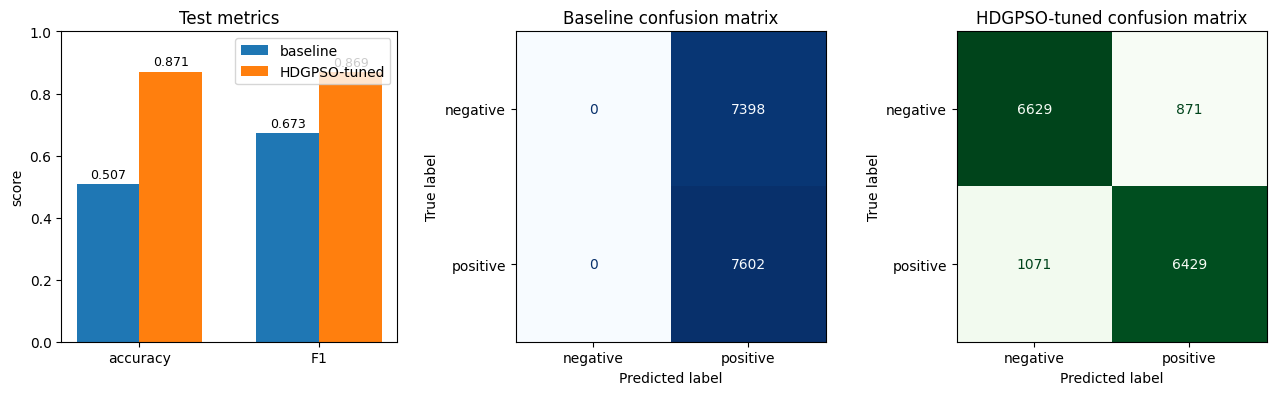

In [38]:
# Visual comparison: a small bar chart of test accuracy and F1,
# plus the two confusion matrices side by side.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

fig = plt.figure(figsize=(13, 4))

# Bar chart on the left
ax_bar = fig.add_subplot(1, 3, 1)
labels = ["accuracy", "F1"]
x = np.arange(len(labels))
width = 0.35
ax_bar.bar(x - width / 2, [base_acc, base_f1], width, label="baseline")
ax_bar.bar(x + width / 2, [hpo_acc, hpo_f1], width, label="HDGPSO-tuned")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(labels)
ax_bar.set_ylim(0, 1.0)
ax_bar.set_ylabel("score")
ax_bar.set_title("Test metrics")
ax_bar.legend()
for i, (b, h) in enumerate(zip([base_acc, base_f1], [hpo_acc, hpo_f1])):
    ax_bar.text(i - width / 2, b + 0.02, f"{b:.3f}", ha="center", fontsize=9)
    ax_bar.text(i + width / 2, h + 0.02, f"{h:.3f}", ha="center", fontsize=9)

# Baseline confusion matrix in the middle
ax_bm = fig.add_subplot(1, 3, 2)
ConfusionMatrixDisplay(
    confusion_matrix=base_cm, display_labels=["negative", "positive"]
).plot(ax=ax_bm, cmap="Blues", colorbar=False, values_format="d")
ax_bm.set_title("Baseline confusion matrix")

# HDGPSO confusion matrix on the right
ax_hm = fig.add_subplot(1, 3, 3)
ConfusionMatrixDisplay(
    confusion_matrix=hpo_cm, display_labels=["negative", "positive"]
).plot(ax=ax_hm, cmap="Greens", colorbar=False, values_format="d")
ax_hm.set_title("HDGPSO-tuned confusion matrix")

plt.tight_layout()
plt.show()